<a href="https://colab.research.google.com/github/Sriyansh-36-AI-NITJ/Concurrent-Programming-Lab/blob/main/Count_pixels_End_Sem_Practical_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install cupy-cuda12x numba matplotlib -q
!nvidia-smi

Mon Jun  1 05:46:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from numba import cuda, uint8
import math, time
from tensorflow.keras.datasets import mnist

print(f"CuPy version: {cp.__version__}")
print(f"CUDA available: {cp.cuda.is_available()}")
print(f"GPU: {cp.cuda.runtime.getDeviceProperties(0)['name']}")

CuPy version: 14.0.1
CUDA available: True
GPU: b'Tesla T4'


In [3]:
# Load dataset (60k train, 10k test, 28×28 grayscale)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Stack all images for batch processing
all_images = np.concatenate([x_train, x_test], axis=0)  # (70000, 28, 28)

# Transfer to GPU memory (host → device)
gpu_images = cp.array(all_images, dtype=cp.uint8)

print(f"Shape on GPU : {gpu_images.shape}")
print(f"GPU memory   : {gpu_images.nbytes / 1e6:.1f} MB")
print(f"Pixel range  : {int(gpu_images.min())} – {int(gpu_images.max())}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape on GPU : (70000, 28, 28)
GPU memory   : 54.9 MB
Pixel range  : 0 – 255


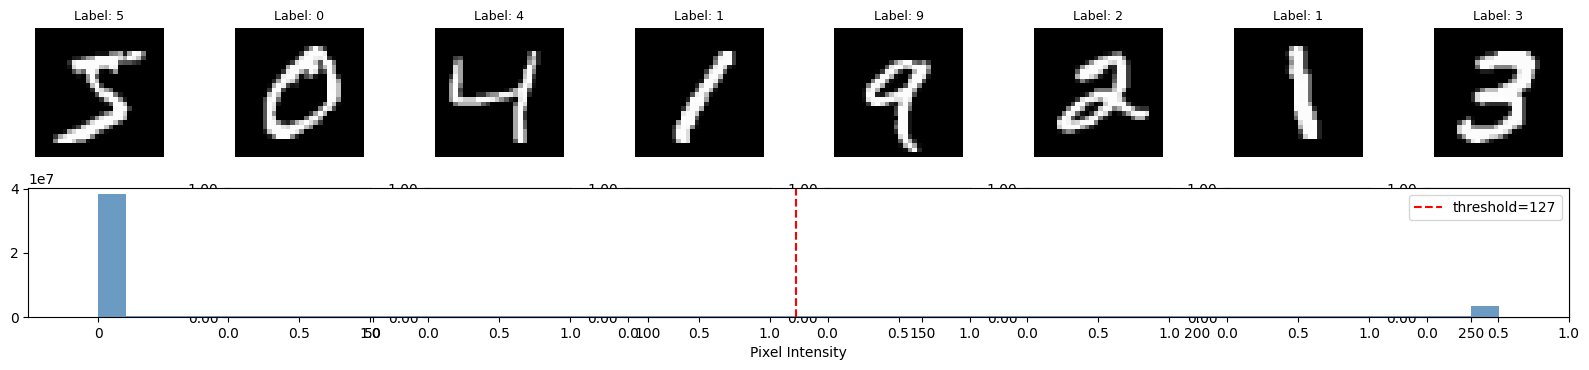

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(x_train[i], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Label: {y_train[i]}", fontsize=9)

# Pixel intensity histogram
axes[1, 0].remove()
ax_hist = fig.add_subplot(2, 1, 2)
ax_hist.hist(x_train.flatten(), bins=50, color='steelblue', alpha=0.8)
ax_hist.axvline(127, color='red', linestyle='--', label='threshold=127')
ax_hist.set_xlabel('Pixel Intensity'); ax_hist.legend()
plt.tight_layout(); plt.show()

In [5]:
def cupy_count_above_threshold(images_gpu, threshold=127):
    """
    Pure CuPy approach — fully vectorized, no explicit kernel.
    Internally launches optimized CUDA reduction kernels.
    """
    mask = images_gpu > threshold            # Boolean GPU array
    per_image = cp.sum(mask, axis=(1, 2))  # Sum over H×W per image
    total = int(cp.sum(per_image))
    return per_image, total

start = time.time()
per_image_counts, total_count = cupy_count_above_threshold(gpu_images, threshold=127)
cp.cuda.Stream.null.synchronize()           # Wait for GPU to finish
t_cupy = (time.time() - start) * 1000

print(f"Total pixels above 127 : {total_count:,}")
print(f"Avg per image          : {float(cp.mean(per_image_counts)):.1f}")
print(f"CuPy time              : {t_cupy:.2f} ms")

Total pixels above 127 : 7,273,790
Avg per image          : 103.9
CuPy time              : 516.94 ms


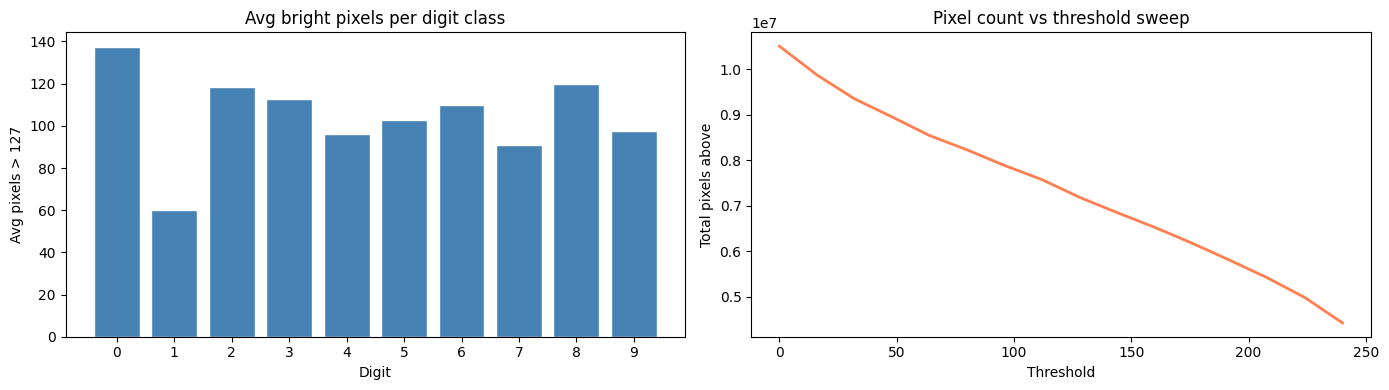

In [6]:
all_labels = np.concatenate([y_train, y_test])

# Per-digit mean pixel count using CuPy
per_image_np = cp.asnumpy(per_image_counts)
digit_means  = {
    d: per_image_np[all_labels == d].mean()
    for d in range(10)
}

digits = list(digit_means.keys())
means  = list(digit_means.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart — avg bright pixels per digit
ax1.bar(digits, means, color='steelblue', edgecolor='white')
ax1.set_xlabel('Digit'); ax1.set_ylabel('Avg pixels > 127')
ax1.set_title('Avg bright pixels per digit class')
ax1.set_xticks(range(10))

# Threshold sweep: count total bright pixels across thresholds
thresholds = range(0, 256, 16)
totals = [
    int(cp.sum(gpu_images > t))
    for t in thresholds
]
ax2.plot(thresholds, totals, color='coral', linewidth=2)
ax2.set_xlabel('Threshold'); ax2.set_ylabel('Total pixels above')
ax2.set_title('Pixel count vs threshold sweep')

plt.tight_layout(); plt.show()
# CPU NumPy baseline

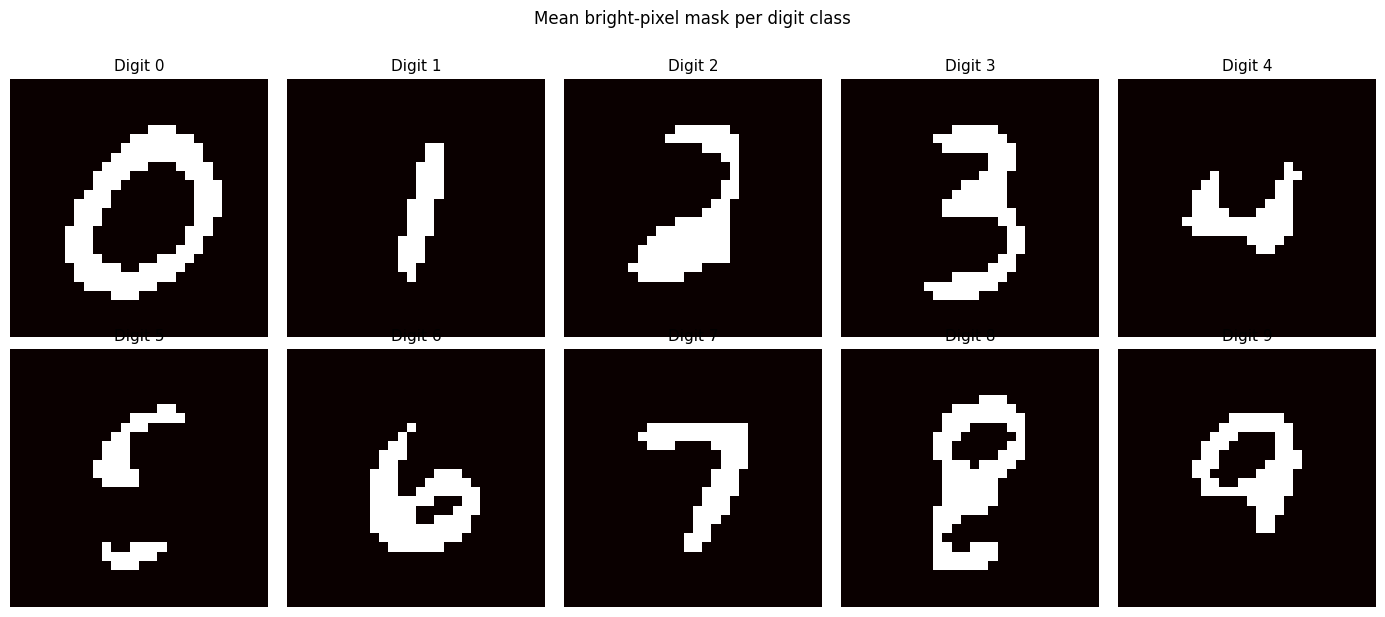

In [7]:
# Mean bright-pixel heatmap per digit (GPU-accelerated)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for digit in range(10):
    mask_d = all_labels == digit
    subset = gpu_images[mask_d].astype(cp.float32)

    # Mean image on GPU, transfer only final 28×28 array
    mean_img = cp.mean(subset, axis=0)
    bright   = (mean_img > 127).astype(cp.float32)

    axes[digit].imshow(cp.asnumpy(bright), cmap='hot', vmin=0, vmax=1)
    axes[digit].set_title(f'Digit {digit}', fontsize=11)
    axes[digit].axis('off')

plt.suptitle('Mean bright-pixel mask per digit class', y=1.02)
plt.tight_layout(); plt.show()